# Day 9: Intro to Deep Learning (PyTorch)

**Dataset:** Titanic cleaned (from Day 2)
**Target:** `survived` (binary)
**Goal:** 2-layer feedforward net, manual train/val loop, gradient accumulation demo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.5.1
CUDA available: False
Using device: cpu


In [2]:
# 1. PREPARE DATA FOR PYTORCH
df = pd.read_csv('../data/titanic_clean.csv')

numeric_features = ['age', 'sibsp', 'parch', 'family_size', 'fare_per_person', 'pclass', 'is_alone']
categorical_features = ['sex', 'embarked', 'deck', 'who', 'age_bin']

# Preprocess with ColumnTransformer (same as Day 8)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X = df[numeric_features + categorical_features]
y = df['survived'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit preprocessor on train only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_processed).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_tensor = torch.FloatTensor(X_test_processed).to(device)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# Train/val split
val_size = int(0.2 * len(X_train_tensor))
train_size = len(X_train_tensor) - val_size

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Input dim: {X_train_processed.shape[1]}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Input dim: 28
Train batches: 18, Val batches: 5


In [3]:
# 2. DEFINE MODEL
class TitanicNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

input_dim = X_train_processed.shape[1]
model = TitanicNet(input_dim).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

TitanicNet(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total parameters: 1921


In [4]:
# 3. LOSS & OPTIMIZER
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 4. TRAINING LOOP
epochs = 50
train_losses = []
val_losses = []
train_aucs = []
val_aucs = []

for epoch in range(epochs):
    # Training
    model.train()
    epoch_train_loss = 0.0
    train_probs = []
    train_targets = []
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # CRITICAL: zero gradients each step
        
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_probs.append(y_pred.detach().cpu().numpy())
        train_targets.append(y_batch.detach().cpu().numpy())
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    epoch_val_loss = 0.0
    val_probs = []
    val_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            epoch_val_loss += loss.item()
            val_probs.append(y_pred.cpu().numpy())
            val_targets.append(y_batch.cpu().numpy())
    
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Compute AUC
    train_auc = roc_auc_score(np.concatenate(train_targets), np.concatenate(train_probs))
    val_auc = roc_auc_score(np.concatenate(val_targets), np.concatenate(val_probs))
    train_aucs.append(train_auc)
    val_aucs.append(val_auc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")

Epoch 10/50 | Train Loss: 0.4204 | Val Loss: 0.3605 | Train AUC: 0.8717 | Val AUC: 0.9337
Epoch 20/50 | Train Loss: 0.4038 | Val Loss: 0.3634 | Train AUC: 0.8677 | Val AUC: 0.9129
Epoch 30/50 | Train Loss: 0.3924 | Val Loss: 0.3702 | Train AUC: 0.8782 | Val AUC: 0.9012
Epoch 40/50 | Train Loss: 0.3773 | Val Loss: 0.3744 | Train AUC: 0.8923 | Val AUC: 0.8992
Epoch 50/50 | Train Loss: 0.3689 | Val Loss: 0.3722 | Train AUC: 0.8883 | Val AUC: 0.9010


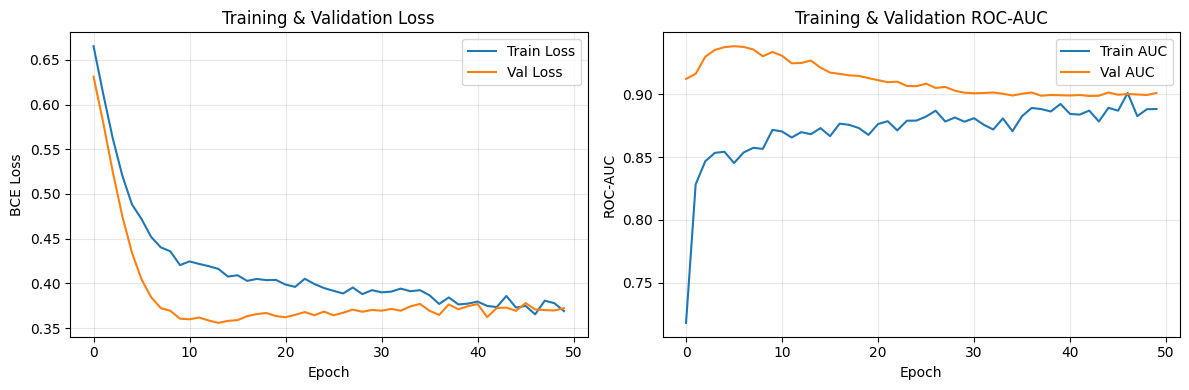

In [5]:
# 5. PLOT LOSS & AUC CURVES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_aucs, label='Train AUC')
axes[1].plot(val_aucs, label='Val AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Training & Validation ROC-AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 6. TEST EVALUATION
model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor).cpu().numpy()
    test_preds = (test_probs > 0.5).astype(int)

test_auc = roc_auc_score(y_test, test_probs)
test_acc = accuracy_score(y_test, test_preds)

print(f"=== PyTorch Neural Net Test Results ===")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Compare with Logistic Regression from Day 5
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)

print(f"\n=== Comparison ===")
print(f"PyTorch NN:  {test_auc:.4f}")
print(f"Logistic Reg: {lr_auc:.4f}")
print(f"Difference:   {test_auc - lr_auc:.4f}")

=== PyTorch Neural Net Test Results ===
Test ROC-AUC: 0.8640
Test Accuracy: 0.8156

=== Comparison ===
PyTorch NN:  0.8640
Logistic Reg: 0.8618
Difference:   0.0022


In [7]:
# 7. GRADIENT ACCUMULATION DEMO
# What happens if we DON'T zero gradients?

model_demo = TitanicNet(input_dim).to(device)
optimizer_demo = optim.Adam(model_demo.parameters(), lr=0.001)
criterion_demo = nn.BCELoss()

# Get one batch
X_batch, y_batch = next(iter(train_loader))

print("=== Gradient Accumulation Demo ===")
print("Running 3 forward/backward passes WITHOUT zero_grad()...")

for i in range(3):
    y_pred = model_demo(X_batch)
    loss = criterion_demo(y_pred, y_batch)
    loss.backward()  # No zero_grad()!
    
    # Check gradient magnitude of first layer
    grad_norm = model_demo.net[0].weight.grad.norm().item()
    print(f"  Pass {i+1}: Loss = {loss.item():.4f}, Grad norm = {grad_norm:.4f}")

print("\nNow WITH zero_grad()...")
model_demo2 = TitanicNet(input_dim).to(device)
optimizer_demo2 = optim.Adam(model_demo2.parameters(), lr=0.001)
criterion_demo2 = nn.BCELoss()

for i in range(3):
    optimizer_demo2.zero_grad()
    y_pred = model_demo2(X_batch)
    loss = criterion_demo2(y_pred, y_batch)
    loss.backward()
    
    grad_norm = model_demo2.net[0].weight.grad.norm().item()
    print(f"  Pass {i+1}: Loss = {loss.item():.4f}, Grad norm = {grad_norm:.4f}")

=== Gradient Accumulation Demo ===
Running 3 forward/backward passes WITHOUT zero_grad()...
  Pass 1: Loss = 0.6921, Grad norm = 0.1854
  Pass 2: Loss = 0.7025, Grad norm = 0.3747
  Pass 3: Loss = 0.7053, Grad norm = 0.5534

Now WITH zero_grad()...
  Pass 1: Loss = 0.7143, Grad norm = 0.2029
  Pass 2: Loss = 0.7312, Grad norm = 0.2101
  Pass 3: Loss = 0.7207, Grad norm = 0.1947


## Summary Notes

- Final test ROC-AUC: 
- vs Logistic Regression: 
- Training stability (loss curves): 
- Gradient accumulation effect: 